# Prediction du Prix de Vente d'une Voiture d'Occasion
## Notebook 3 : Construction et Evaluation des Modeles ML
**EHTP - MSDE Edition 7 | Module 5 : Machine Learning**
---

## I. Chargement des Librairies et des Donnees

Ce notebook constitue le coeur du pipeline ML. Nous allons entrainer et evaluer
11 algorithmes de regression sur les donnees preprocessees, puis comparer leurs
performances a travers plusieurs indicateurs d'evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("Librairies chargees avec succes")

Librairies chargees avec succes


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"y_train : {y_train.shape} | y_test : {y_test.shape}")

X_train : (153498, 9) | X_test : (38375, 9)
y_train : (153498,) | y_test : (38375,)


## II. Definition des Modeles et de la Fonction d'Evaluation

Nous definissons une fonction d'evaluation unique qui calcule pour chaque modele :
- **R2 (coefficient de determination)** : mesure la proportion de variance expliquee par le modele. Plus il est proche de 1, meilleur est le modele.
- **MAE (Mean Absolute Error)** : erreur moyenne absolue en unites logarithmiques.
- **RMSE (Root Mean Squared Error)** : penalise davantage les grandes erreurs.
- **MAPE (Mean Absolute Percentage Error)** : erreur relative en pourcentage sur le prix reel.
- **CV R2** : R2 moyen en validation croisee 5-fold pour detecter l'overfitting.

In [3]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_test)

    # Retour en prix reel pour le MAPE
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    return {
        'Modele'   : name,
        'R2'       : round(r2, 4),
        'MAE'      : round(mae, 4),
        'RMSE'     : round(rmse, 4),
        'MAPE (%)'  : round(mape, 2),
        'CV R2 Moy': round(cv_mean, 4),
        'CV R2 Std': round(cv_std, 4),
        'Temps (s)': round(elapsed, 2)
    }

In [4]:
models = {
    'Regression Lineaire'   : LinearRegression(),
    'Ridge'                 : Ridge(alpha=1.0),
    'Lasso'                 : Lasso(alpha=0.001),
    'ElasticNet'            : ElasticNet(alpha=0.001, l1_ratio=0.5),
    'Arbre de Decision'     : DecisionTreeRegressor(random_state=42),
    'Random Forest'         : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Extra Trees'           : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'               : XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM'              : LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
    'KNN Regressor'         : KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
}

## III. Entrainement et Evaluation des 11 Modeles

Chaque modele est entraine sur X_train et evalue sur X_test.
La validation croisee 5-fold sur X_train permet de detecter un eventuel overfitting.

In [5]:
results = []
print("Entrainement en cours...\n")

for name, model in models.items():
    print(f"  -> {name}...")
    res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)
    print(f"     R2={res['R2']} | RMSE={res['RMSE']} | MAPE={res['MAPE (%)']}% | Temps={res['Temps (s)']}s")

df_results = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print("\nEntrainement termine.")

Entrainement en cours...

  -> Regression Lineaire...


     R2=0.7244 | RMSE=0.5444 | MAPE=46.19% | Temps=0.07s
  -> Ridge...


     R2=0.7244 | RMSE=0.5444 | MAPE=46.19% | Temps=0.04s
  -> Lasso...


     R2=0.7243 | RMSE=0.5445 | MAPE=46.21% | Temps=0.1s
  -> ElasticNet...


     R2=0.7243 | RMSE=0.5445 | MAPE=46.21% | Temps=0.05s
  -> Arbre de Decision...


...

     R2=0.8331 | RMSE=0.4237 | MAPE=35.21% | Temps=16.57s
  -> Extra Trees...


     R2=0.8496 | RMSE=0.4021 | MAPE=31.34% | Temps=3.93s
  -> XGBoost...


     R2=0.8645 | RMSE=0.3817 | MAPE=30.78% | Temps=0.63s
  -> LightGBM...


     R2=0.8553 | RMSE=0.3944 | MAPE=32.12% | Temps=0.61s
  -> KNN Regressor...


     R2=0.8246 | RMSE=0.4343 | MAPE=36.63% | Temps=0.54s

Entrainement termine.


## IV. Tableau Comparatif des Performances

Le tableau suivant presente les metriques de chaque modele, trie par R2 decroissant.
Un bon modele possede un R2 eleve, un RMSE et MAE faibles, et un ecart faible entre R2 test et CV R2 (absence d'overfitting).

In [6]:
df_results.style\
    .background_gradient(subset=['R2', 'CV R2 Moy'], cmap='Greens')\
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE (%)'], cmap='Reds_r')\
    .set_caption("Tableau comparatif des 11 modeles ML")\
    .format({'R2': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}',
             'MAPE (%)': '{:.2f}', 'CV R2 Moy': '{:.4f}', 'CV R2 Std': '{:.4f}'})

,Modele,R2,MAE,RMSE,MAPE (%),CV R2 Moy,CV R2 Std,Temps (s)
0,XGBoost,0.8645,0.2766,0.3817,30.78,0.8610,0.0018,0.630000
1,Random Forest,0.8577,0.2760,0.3912,30.61,0.8522,0.0021,4.950000
2,LightGBM,0.8553,0.2873,0.3944,32.12,0.8533,0.0024,0.610000
3,Extra Trees,0.8496,0.2800,0.4021,31.34,0.8430,0.0018,3.930000
4,Gradient Boosting,0.8331,0.3105,0.4237,35.21,0.8306,0.0025,16.570000
5,KNN Regressor,0.8246,0.3096,0.4343,36.63,0.8164,0.0016,0.540000
6,Arbre de Decision,0.8180,0.3007,0.4424,34.22,0.8077,0.0033,0.380000
7,Regression Lineaire,0.7244,0.3999,0.5444,46.19,0.7190,0.0039,0.070000
8,Ridge,0.7244,0.3999,0.5444,46.19,0.7190,0.0039,0.040000
9,Lasso,0.7243,0.3999,0.5445,46.21,0.7190,0.0039,0.100000


## V. Visualisation des Performances

### V.1 Tableau de Bord Comparatif des Performances

Ce tableau de bord regroupe les 4 indicateurs cles en une seule figure :
- **R2** : qualite globale du modele (plus haut = meilleur)
- **RMSE** : penalise les grandes erreurs (plus bas = meilleur)
- **MAPE** : erreur en pourcentage sur le prix reel (plus bas = meilleur)
- **Temps d'entrainement** : critere pratique pour le deploiement

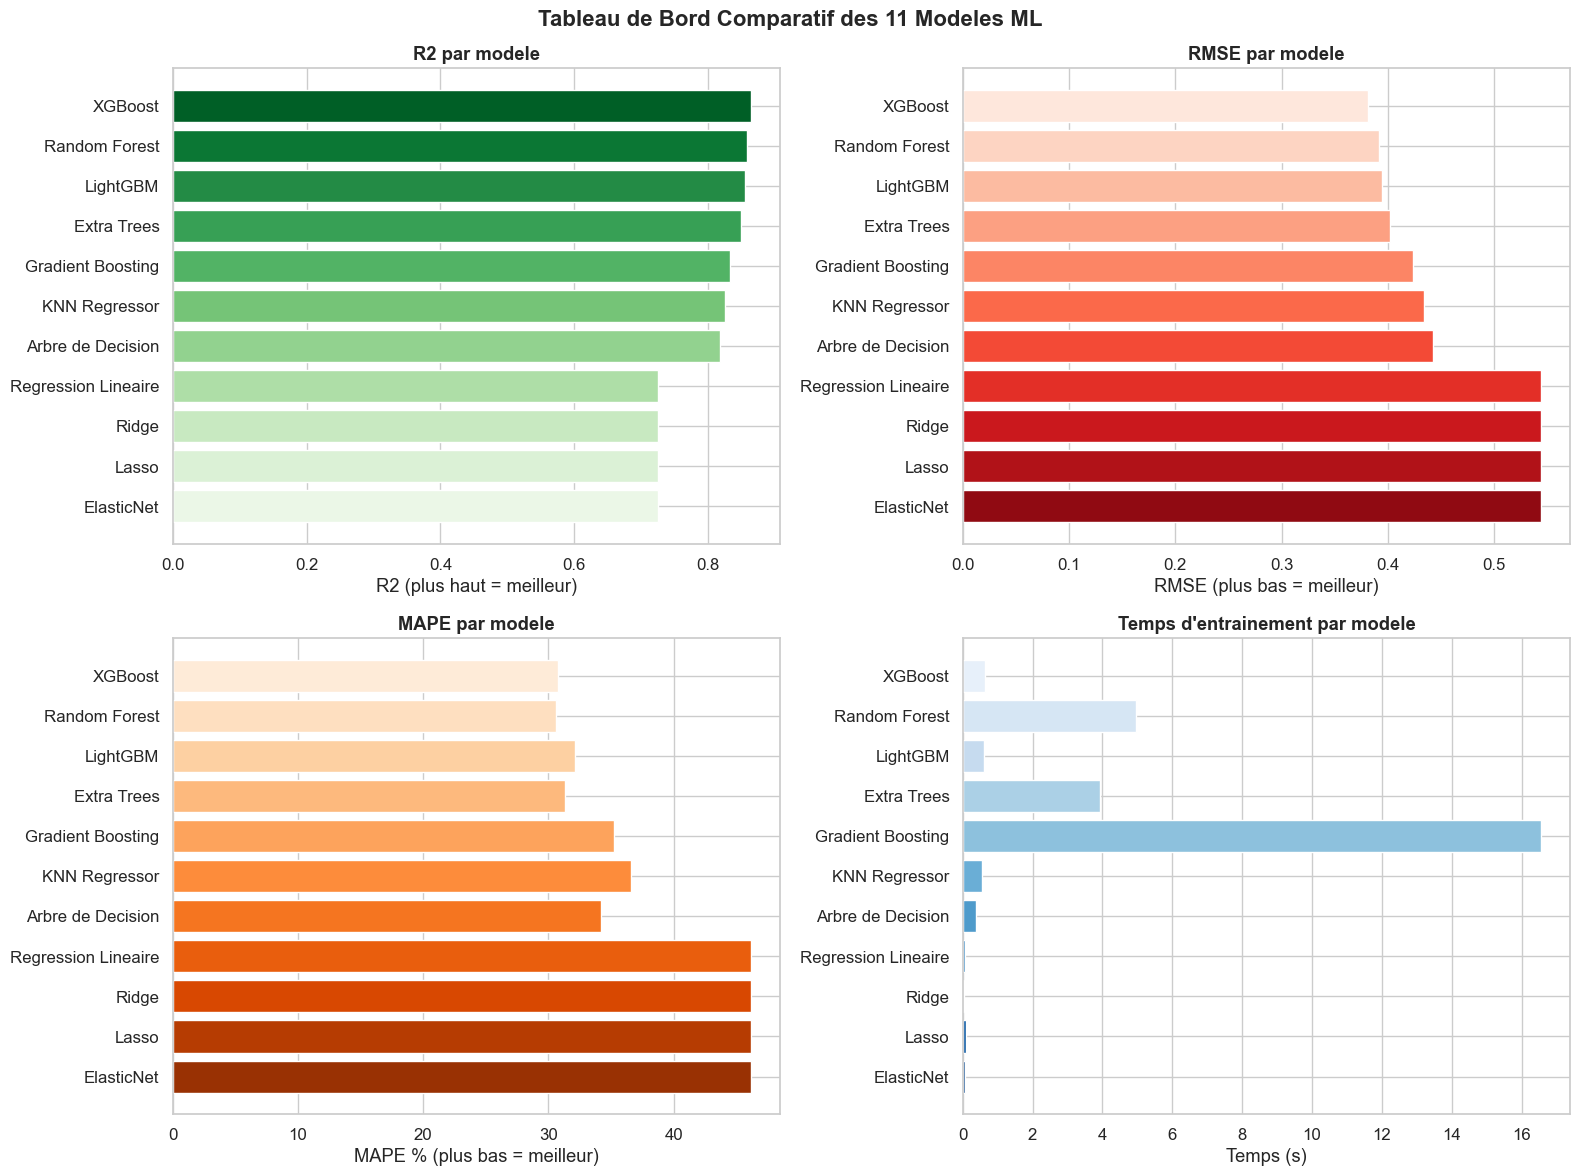

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R2
colors_r2 = sns.color_palette("Greens_r", len(df_results))
axes[0, 0].barh(df_results['Modele'], df_results['R2'], color=colors_r2, edgecolor='white')
axes[0, 0].set_title('R2 par modele', fontweight='bold')
axes[0, 0].set_xlabel('R2 (plus haut = meilleur)')
axes[0, 0].invert_yaxis()

# RMSE
colors_rmse = sns.color_palette("Reds", len(df_results))
axes[0, 1].barh(df_results['Modele'], df_results['RMSE'], color=colors_rmse, edgecolor='white')
axes[0, 1].set_title('RMSE par modele', fontweight='bold')
axes[0, 1].set_xlabel('RMSE (plus bas = meilleur)')
axes[0, 1].invert_yaxis()

# MAPE
colors_mape = sns.color_palette("Oranges", len(df_results))
axes[1, 0].barh(df_results['Modele'], df_results['MAPE (%)'], color=colors_mape, edgecolor='white')
axes[1, 0].set_title('MAPE par modele', fontweight='bold')
axes[1, 0].set_xlabel('MAPE % (plus bas = meilleur)')
axes[1, 0].invert_yaxis()

# Temps d'entrainement
colors_temps = sns.color_palette("Blues", len(df_results))
axes[1, 1].barh(df_results['Modele'], df_results['Temps (s)'], color=colors_temps, edgecolor='white')
axes[1, 1].set_title("Temps d'entrainement par modele", fontweight='bold')
axes[1, 1].set_xlabel('Temps (s)')
axes[1, 1].invert_yaxis()

plt.suptitle('Tableau de Bord Comparatif des 11 Modeles ML', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/tableau_bord_comparatif.png', dpi=150, bbox_inches='tight')
plt.show()

### V.4 R2 Test vs R2 Cross-Validation

Ce graphique permet de detecter l'overfitting : si le R2 Test est nettement
superieur au CV R2, le modele a sur-appris les donnees d'entrainement et ne
generalisera pas bien sur de nouvelles donnees.

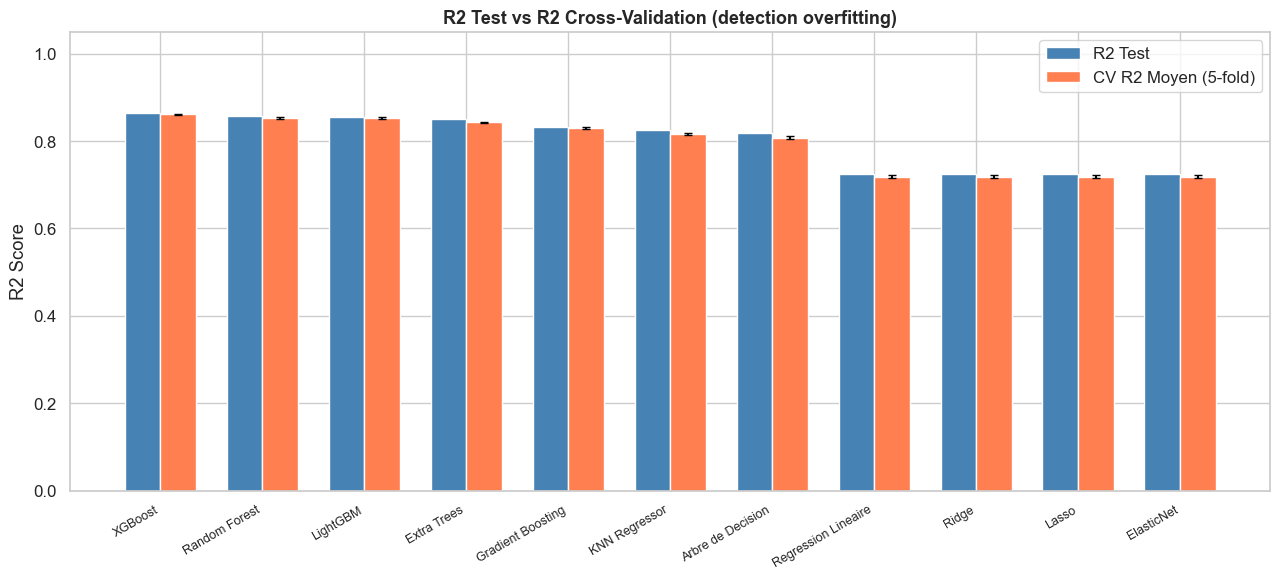

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['R2'], width, label='R2 Test',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, df_results['CV R2 Moy'], width, label='CV R2 Moyen (5-fold)',
               color='coral', edgecolor='white')

ax.errorbar(x + width/2, df_results['CV R2 Moy'],
            yerr=df_results['CV R2 Std'], fmt='none', color='black', capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(df_results['Modele'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('R2 Score')
ax.set_title('R2 Test vs R2 Cross-Validation (detection overfitting)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../report/r2_test_vs_cv.png', dpi=150, bbox_inches='tight')
plt.show()

### V.6 Predictions vs Valeurs Reelles (3 meilleurs modeles)

Ce graphique compare visuellement les predictions aux valeurs reelles.
Un modele parfait alignerait tous les points sur la droite y=x (ligne rouge).
Plus les points sont proches de cette droite, plus le modele est precis.

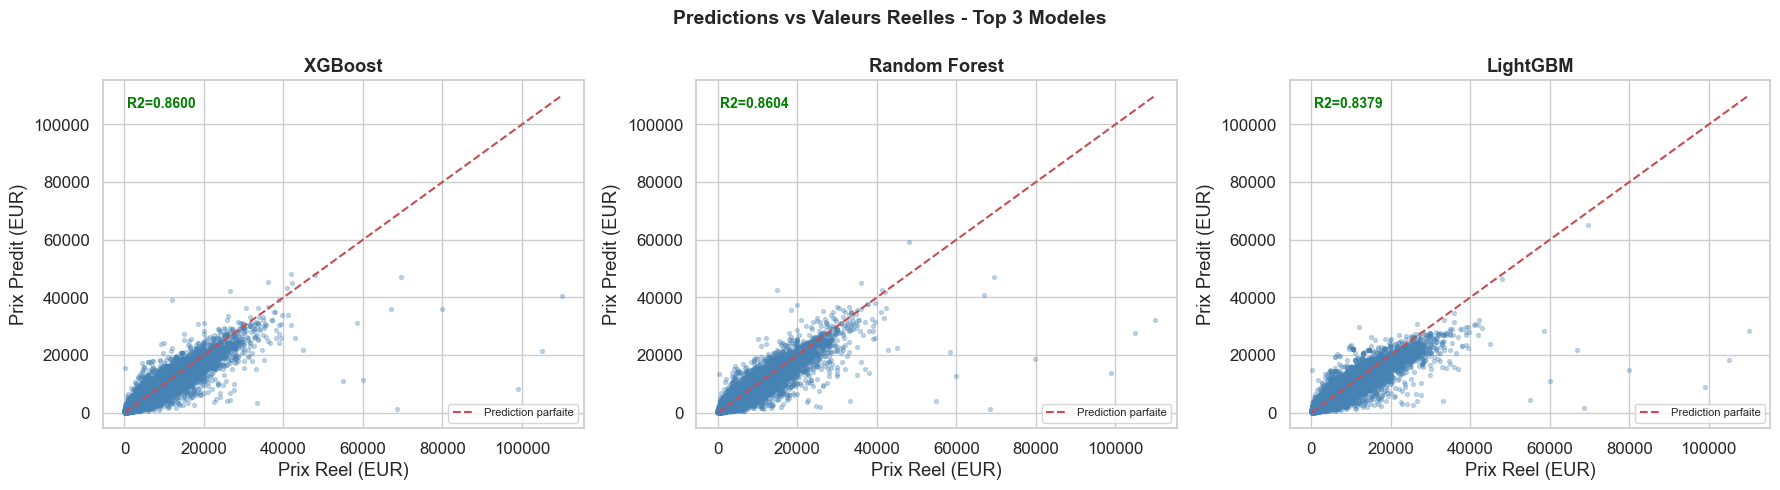

In [9]:
top3_names = df_results.head(3)['Modele'].tolist()
top3_models = {name: models[name] for name in top3_names}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(top3_models.items()):
    y_pred = model.predict(X_test)

    # Retour en prix reel
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred)

    axes[i].scatter(y_test_real, y_pred_real, alpha=0.3, s=8, color='steelblue')
    min_val = min(y_test_real.min(), y_pred_real.min())
    max_val = max(y_test_real.max(), y_pred_real.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Prediction parfaite')
    axes[i].set_xlabel('Prix Reel (EUR)')
    axes[i].set_ylabel('Prix Predit (EUR)')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].legend(fontsize=8)
    r2 = r2_score(y_test_real, y_pred_real)
    axes[i].text(0.05, 0.92, f'R2={r2:.4f}', transform=axes[i].transAxes,
                 fontsize=10, color='green', fontweight='bold')

plt.suptitle('Predictions vs Valeurs Reelles - Top 3 Modeles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/predictions_vs_reelles.png', dpi=150, bbox_inches='tight')
plt.show()

### V.7 Distribution des Residus (3 meilleurs modeles)

Les residus sont les erreurs de prediction (valeur reelle - valeur predite).
Un bon modele produit des residus distribues normalement autour de zero,
sans biais systematique dans une direction.

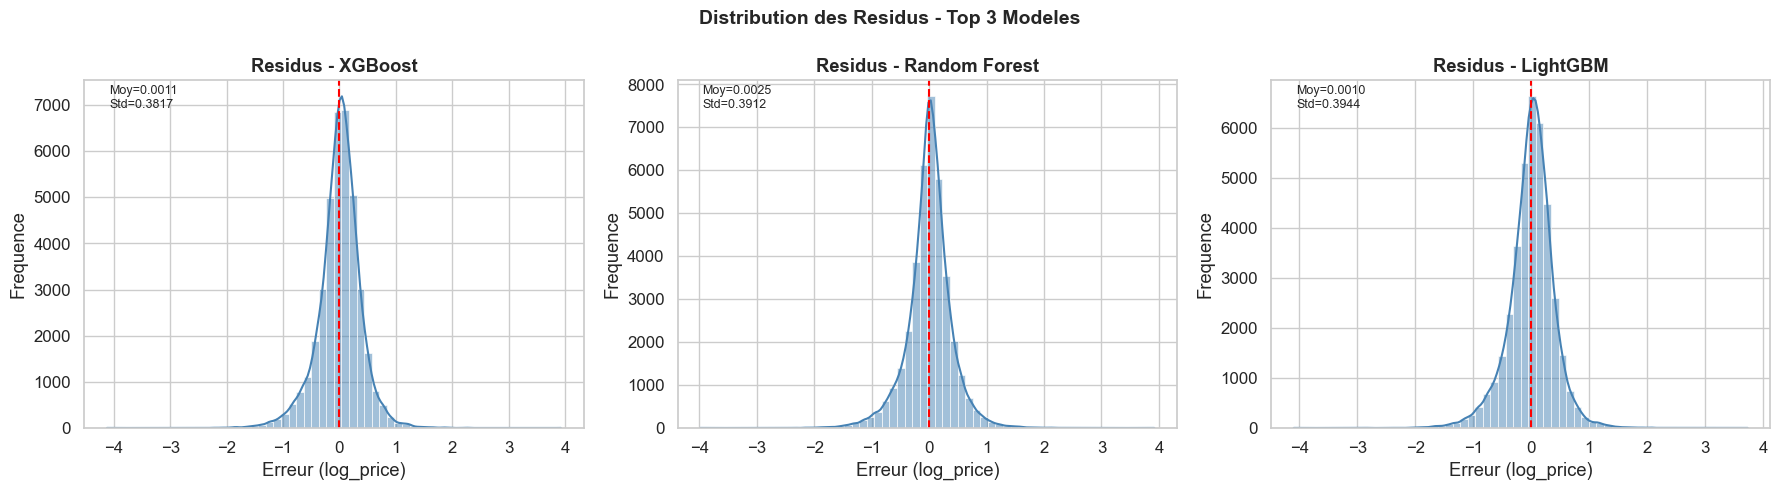

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(top3_models.items()):
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred

    sns.histplot(residuals, bins=60, kde=True, ax=axes[i], color='steelblue')
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[i].set_title(f'Residus - {name}', fontweight='bold')
    axes[i].set_xlabel('Erreur (log_price)')
    axes[i].set_ylabel('Frequence')
    axes[i].text(0.05, 0.92, f'Moy={residuals.mean():.4f}\nStd={residuals.std():.4f}',
                 transform=axes[i].transAxes, fontsize=9)

plt.suptitle('Distribution des Residus - Top 3 Modeles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/residus.png', dpi=150, bbox_inches='tight')
plt.show()

## VI. Selection des 3 Modeles Candidats pour le Tuning

Les 3 modeles candidats sont selectionnes selon les criteres suivants :
- R2 le plus eleve sur le jeu de test
- Ecart faible entre R2 test et CV R2 (pas d'overfitting)
- MAPE acceptable (erreur metier raisonnable)
- Temps d'entrainement raisonnable pour le deploiement

In [11]:
print("Top 3 modeles selectionnes pour le tuning :\n")
print(df_results.head(3)[['Modele', 'R2', 'RMSE', 'MAPE (%)', 'CV R2 Moy', 'CV R2 Std']].to_string(index=False))

print("\nJustification :")
for _, row in df_results.head(3).iterrows():
    ecart = abs(row['R2'] - row['CV R2 Moy'])
    overfitting = "leger overfitting detecte" if ecart > 0.05 else "pas d'overfitting"
    print(f"  {row['Modele']} : R2={row['R2']} | CV R2={row['CV R2 Moy']} | Ecart={ecart:.4f} -> {overfitting}")

Top 3 modeles selectionnes pour le tuning :

       Modele     R2   RMSE  MAPE (%)  CV R2 Moy  CV R2 Std
      XGBoost 0.8645 0.3817   30.7800     0.8610     0.0018
Random Forest 0.8577 0.3912   30.6100     0.8522     0.0021
     LightGBM 0.8553 0.3944   32.1200     0.8533     0.0024

Justification :
  XGBoost : R2=0.8645 | CV R2=0.861 | Ecart=0.0035 -> pas d'overfitting
  Random Forest : R2=0.8577 | CV R2=0.8522 | Ecart=0.0055 -> pas d'overfitting
  LightGBM : R2=0.8553 | CV R2=0.8533 | Ecart=0.0020 -> pas d'overfitting


## VII. Synthese de la Modelisation

### Conclusions

**Classement des modeles :**
Les modeles ensemblistes (Random Forest, XGBoost, LightGBM, Extra Trees, Gradient Boosting)
surpassent largement les modeles lineaires (Regression Lineaire, Ridge, Lasso, ElasticNet),
ce qui confirme que la relation entre les caracteristiques d'un vehicule et son prix
est fortement non-lineaire.

**Observations sur l'overfitting :**
L'Arbre de Decision montre un ecart important entre R2 test et CV R2,
signe d'overfitting. Les modeles ensemblistes sont plus stables
grace a leur mecanisme de bagging/boosting.

**Observations sur le MAPE :**
Le MAPE des meilleurs modeles indique l'erreur moyenne en pourcentage
sur le prix reel - un critere directement interpretable pour le metier.

**Prochaine etape :**
Les 3 meilleurs modeles seront soumis au tuning des hyperparametres
dans le Notebook 04 pour optimiser leurs performances finales.